<a href="https://colab.research.google.com/github/ryanclaytoncollins-design/ITAI_ML_FirstRepo_Ryan/blob/main/L03_Ryan_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import essential libraries\n",=
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

print("All libraries imported successfully!"),
print("Ready to start our machine learning journey!")


All libraries imported successfully!
Ready to start our machine learning journey!


In [ ]:
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame for easier handling
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df['wine_class'] = wine_data.target
df['wine_class_name'] = [wine_data.target_names[i] for i in wine_data.target]

print("Dataset Information: ")
print(f"Shape: {df.shape}")
print(f"Features: {len(wine_data.feature_names)}")
print(f"Classes: {wine_data.target_names}")
print(f"\nFirst 5 rows:")
print(df.head())


Dataset Information: 
Shape: (178, 15)
Features: 13
Classes: ['class_0' 'class_1' 'class_2']

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.3

In [ ]:
# Explore the dataset structure
print("Dataset Overview:")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Features (input variables): {len(df.columns) - 2}")  # -2 for target columns
print(f"Target classes: {df['wine_class_name'].unique()}")
print(f"\\nClass distribution:"),
print(df['wine_class_name'].value_counts())

# Check for missing values\n",
print(f"\nMissing values: {df.isnull().sum().sum()}")
print("\u2705 No missing values - this is a clean dataset!")


Dataset Overview:
Total samples: 178
Features (input variables): 13
Target classes: [np.str_('class_0') np.str_('class_1') np.str_('class_2')]
\nClass distribution:
wine_class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Missing values: 0
✅ No missing values - this is a clean dataset!


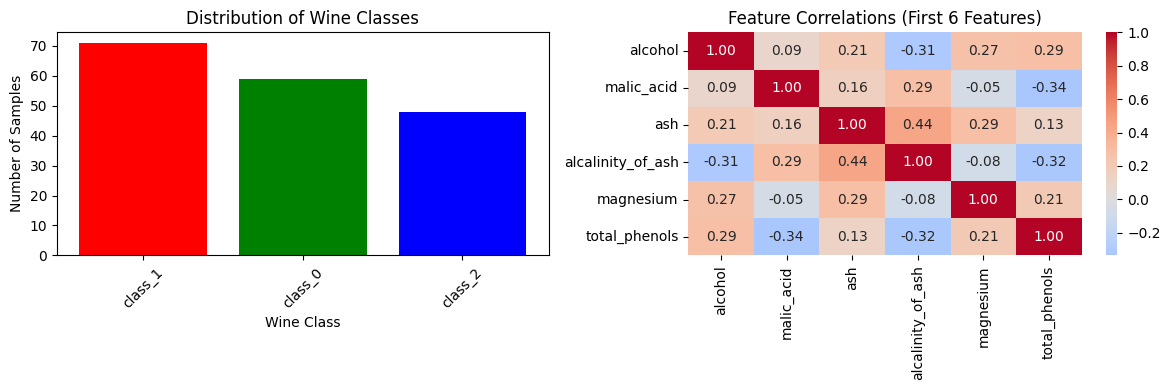

ud83d� EDA helps us understand:
- Class balance (are all classes equally represented?)
- Feature relationships (which features are correlated?)
- Data quality (any outliers or issues?)


In [ ]:
# Visualize class distribution
plt.figure(figsize=(12, 4))

# Subplot 1: Class distribution
plt.subplot(1, 2, 1)
class_counts = df['wine_class_name'].value_counts()
plt.bar(class_counts.index, class_counts.values, color=['red', 'green', 'blue'])
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# Subplot 2: Feature correlation heatmap (first 6 features for clarity)
plt.subplot(1, 2, 2)
correlation_matrix = df.iloc[:, :6].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlations (First 6 Features)')

plt.tight_layout()
plt.show()

print("ud83d\udcca EDA helps us understand:")
print("- Class balance (are all classes equally represented?)")
print("- Feature relationships (which features are correlated?)")
print("- Data quality (any outliers or issues?)")


In [ ]:
# Step 1: Data Preparation
print("Step 1: Data Preparation")
print("=" * 30)

# Select features (X) and target (y)
# For simplicity, let's use the first 4 features
feature_names = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols']
X = df[feature_names]
y = df['wine_class']

print(f"Selected features: {feature_names}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Display first few rows
print("\nFirst 5 samples:")
print(X.head())


Step 1: Data Preparation
Selected features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols']
Feature matrix shape: (178, 6)
Target vector shape: (178,)

First 5 samples:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols
0    14.23        1.71  2.43               15.6      127.0           2.80
1    13.20        1.78  2.14               11.2      100.0           2.65
2    13.16        2.36  2.67               18.6      101.0           2.80
3    14.37        1.95  2.50               16.8      113.0           3.85
4    13.24        2.59  2.87               21.0      118.0           2.80


In [ ]:
# Step 2: Data Splitting
print("Step 2: Data Splitting")
print("=" * 30)

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducible results
    stratify=y          # Maintain class proportions
        )

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training classes: {np.bincount(y_train)}")
print(f"Testing classes: {np.bincount(y_test)}")

print("\n Why split data?")
print("- Training set: Teach the model")
print("- Testing set: Evaluate performance on unseen data")
print("- This prevents overfitting (memorizing vs. learning)")


Step 2: Data Splitting
Training set: 142 samples
Testing set: 36 samples
Training classes: [47 57 38]
Testing classes: [12 14 10]

 Why split data?
- Training set: Teach the model
- Testing set: Evaluate performance on unseen data
- This prevents overfitting (memorizing vs. learning)


In [ ]:
# Step 3: Model Training
print("Step 3: Model Training")
print("=" * 30)

# Create and train two different models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=3)
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model

    print(f" {name} training completed!")

print("\n What happened during training?")
print("- Models learned patterns from training data")
print("- They found relationships between features and wine classes")
print("- Now they can make predictions on new data!")


Step 3: Model Training

Training Logistic Regression...
 Logistic Regression training completed!

Training Decision Tree...
 Decision Tree training completed!

 What happened during training?
- Models learned patterns from training data
- They found relationships between features and wine classes
- Now they can make predictions on new data!


In [ ]:
# Step 4: Model Evaluation\n",
print("Step 4: Model Evaluation")
print("=" * 30)

results = {}

for name, model in trained_models.items():
    # Make predictions\n",
    y_pred = model.predict(X_test)

    # Calculate accuracy\n",
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"\n{name} Results:"),
    print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

    # Detailed classification report
    print("\n Detailed Performance:")
    print(classification_report(y_test, y_pred, target_names=wine_data.target_names))

# Compare models\n",
print("\n Model Comparison:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.3f}")

best_model = max(results, key=results.get)
print(f"\n Best performing model: {best_model}")


Step 4: Model Evaluation

Logistic Regression Results:
Accuracy: 0.722 (72.2%)

 Detailed Performance:
              precision    recall  f1-score   support

     class_0       0.71      1.00      0.83        12
     class_1       0.75      0.43      0.55        14
     class_2       0.73      0.80      0.76        10

    accuracy                           0.72        36
   macro avg       0.73      0.74      0.71        36
weighted avg       0.73      0.72      0.70        36


Decision Tree Results:
Accuracy: 0.861 (86.1%)

 Detailed Performance:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.85      0.79      0.81        14
     class_2       0.80      0.80      0.80        10

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36


 Model Comparison:
Logistic Regression: 0.722
Decision Tree: 0

Step 5: Model Interpretation


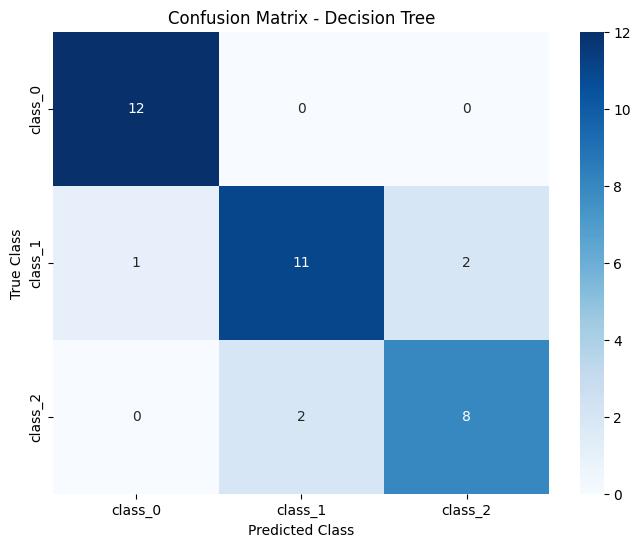


 Interpreting the Confusion Matrix:
- Diagonal values: Correct predictions
- Off-diagonal values: Misclassifications
- Perfect model would have all values on diagonal


In [ ]:
# Step 5: Model Interpretation\n",
print("Step 5: Model Interpretation")
print("=" * 30)

# Visualize confusion matrix for the best model\n",
best_model_obj = trained_models[best_model]
y_pred_best = best_model_obj.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names)
plt.title(f'Confusion Matrix - {best_model}')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

print(f"\n Interpreting the Confusion Matrix:")
print("- Diagonal values: Correct predictions")
print("- Off-diagonal values: Misclassifications")
print("- Perfect model would have all values on diagonal")


In [ ]:
# Understanding Different Data Types in ML\n",
print("Understanding Data Types in Machine Learning")
print("=" * 45)

# Create examples of different data types\n",
data_examples = {
    'Numerical (Continuous)': [23.5, 45.2, 67.8, 12.1, 89.3],
    'Numerical (Discrete)': [1, 5, 3, 8, 2],
    'Categorical (Nominal)': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Categorical (Ordinal)': ['Low', 'Medium', 'High', 'Medium', 'Low'],
    'Text': ['Hello world', 'Machine learning', 'Data science', 'Python programming', 'AI revolution'],
    'Boolean': [True, False, True, True, False]
}

for data_type, examples in data_examples.items():
    print(f"\n{data_type}:")
    print(f"  Examples: {examples}")
    print(f"  Use case: ", end="")

    if 'Continuous' in data_type:
        print("Regression problems (predicting prices, temperatures)")
    elif 'Discrete' in data_type:
        print("Counting problems (number of items, ratings)")
    elif 'Nominal' in data_type:
        print("Classification without order (colors, categories)")
    elif 'Ordinal' in data_type:
        print("Classification with order (ratings, sizes)")
    elif 'Text' in data_type:
        print("Natural language processing (sentiment analysis, translation)")
    elif 'Boolean' in data_type:
        print("Binary classification (yes/no, spam/not spam)")

print("\n Key Insight: Different data types require different preprocessing and algorithms!")


Understanding Data Types in Machine Learning

Numerical (Continuous):
  Examples: [23.5, 45.2, 67.8, 12.1, 89.3]
  Use case: Regression problems (predicting prices, temperatures)

Numerical (Discrete):
  Examples: [1, 5, 3, 8, 2]
  Use case: Counting problems (number of items, ratings)

Categorical (Nominal):
  Examples: ['Red', 'Blue', 'Green', 'Red', 'Blue']
  Use case: Classification without order (colors, categories)

Categorical (Ordinal):
  Examples: ['Low', 'Medium', 'High', 'Medium', 'Low']
  Use case: Classification with order (ratings, sizes)

Text:
  Examples: ['Hello world', 'Machine learning', 'Data science', 'Python programming', 'AI revolution']
  Use case: Natural language processing (sentiment analysis, translation)

Boolean:
  Examples: [True, False, True, True, False]
  Use case: Binary classification (yes/no, spam/not spam)

 Key Insight: Different data types require different preprocessing and algorithms!


In [ ]:
# Task 1: Try different features\n",
print("Task 1: Experiment with Different Features")
print("=" * 40)

# Your task: Select 3 different features and build a model\n",
# Available features:\n",
print("Available features:")
for i, feature in enumerate(wine_data.feature_names):
    print(f"{i+1:2d}. {feature}")

# TODO: Replace these with your chosen features\n",
your_features = ['hue', 'proline', 'magnesium']  # Modify this list\n",

# Build model with your features\n",
X_your = df[your_features]
X_train_your, X_test_your, y_train_your, y_test_your = train_test_split(
    X_your, y, test_size=0.2, random_state=42, stratify=y
)

# Train a logistic regression model\n",
your_model = LogisticRegression(random_state=42)
your_model.fit(X_train_your, y_train_your)

# Evaluate\n",
y_pred_your = your_model.predict(X_test_your)
your_accuracy = accuracy_score(y_test_your, y_pred_your)

print(f"\nYour model features: {your_features}")
print(f"Your model accuracy: {your_accuracy:.3f} ({your_accuracy*100:.1f}%)")

# Compare with original model\n",
print(f"Original model accuracy: {results['Logistic Regression']:.3f}")
if your_accuracy > results['Logistic Regression']:
    print("Great job! Your feature selection improved the model!")
else:
    print(" Try different features to see if you can improve performance!")


Task 1: Experiment with Different Features
Available features:
 1. alcohol
 2. malic_acid
 3. ash
 4. alcalinity_of_ash
 5. magnesium
 6. total_phenols
 7. flavanoids
 8. nonflavanoid_phenols
 9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline

Your model features: ['hue', 'proline', 'magnesium']
Your model accuracy: 0.917 (91.7%)
Original model accuracy: 0.722
Great job! Your feature selection improved the model!


In [ ]:
# Assessment Task 1: Identify the ML type\n",
print("Assessment Task 1: Identify Machine Learning Types")
print("=" * 50)

# For each scenario, identify if it's Supervised, Unsupervised, or Reinforcement Learning\n",

scenarios = [
    "Predicting house prices based on size, location, and age",
    "Grouping customers by purchasing behavior without knowing groups beforehand",
    "Teaching a robot to play chess by playing many games",
    "Classifying emails as spam or not spam using labeled examples",
    "Finding hidden topics in news articles without predefined categories"
]

# Your answers (replace 'TYPE' with Supervised, Unsupervised, or Reinforcement)\n",
your_answers = [
    "Supervised",      # Scenario 1
    "Unsupervised",    # Scenario 2
    "Reinforcement",   # Scenario 3
    "Supervised",      # Scenario 4
    "Unsupervised"     # Scenario 5
]

# Check answers\n",
correct_answers = ["Supervised", "Unsupervised", "Reinforcement", "Supervised", "Unsupervised"]

print("Scenario Analysis:")
score = 0
for i, (scenario, your_answer, correct) in enumerate(zip(scenarios, your_answers, correct_answers)):
    is_correct = your_answer == correct
    score += is_correct
    status = "\u2705" if is_correct else "\u274c"
    print(f"{status} {i+1}. {scenario}")
    print(f"   Your answer: {your_answer} | Correct: {correct}")
    print()

print(f"Score: {score}/{len(scenarios)} ({score/len(scenarios)*100:.0f}%)")


Assessment Task 1: Identify Machine Learning Types
Scenario Analysis:
✅ 1. Predicting house prices based on size, location, and age
   Your answer: Supervised | Correct: Supervised

✅ 2. Grouping customers by purchasing behavior without knowing groups beforehand
   Your answer: Unsupervised | Correct: Unsupervised

✅ 3. Teaching a robot to play chess by playing many games
   Your answer: Reinforcement | Correct: Reinforcement

✅ 4. Classifying emails as spam or not spam using labeled examples
   Your answer: Supervised | Correct: Supervised

✅ 5. Finding hidden topics in news articles without predefined categories
   Your answer: Unsupervised | Correct: Unsupervised

Score: 5/5 (100%)


## Your Reflection and Analysis\n",
        "\n",
        "**Instructions**: Complete the reflection below by editing this markdown cell.\n",
        "\n",
        "### My Understanding of Machine Learning Types\n",
        "\n",
        "**Supervised Learning**: Supervised learning in machine learning is when the data sets being used are pre labled and usually already have pre assigned desired outputs.",
        "\n",
        "**Unsupervised Learning**: Unsupervised learning in machine learning occurs when the raw unlabled data is used without any intervention from people",
        "\n",
        "**Reinforcement Learning**: Reinforcement Learning with machine learning happens when the machine uses trial and error to slowly figure out the optimal answer with each mistake getting it closer to the best outcome",
        "\n",
        "### My Analysis of the Wine Classification Project\n",
        "\n",
        "**Best performing model**: In my opinion unsupervised learning ",
        "\n",
        "**Why do you think this model performed better?**: using the raw data allows for a more natural intake of the data sets. With the other versions of machine learning either taking too long or have human influence",
        "\n",
        "**What would you try next to improve performance?**: the speed at which the data can be input",
        "\n",
        "### Real-World Application Ideas\n",
        "\n",
        "**Industry of Interest**: Education is an area of intrest that I believe could have alot of help from some aspects in machine learning",
        "\n",
        "**ML Problem**: Machine learning could help with finding students on downward trends before they fully fail or even look at what classes are struggling with and helping teachers understand what they need to focus on",
        "\n",
        "**Type of ML**: This would need unsupervised machine learning because with supervised it would end up suggesting mostly what the teachers already see and we dont need to look for the most optimal path with reinforcement",
        "\n",
        "**Data Needed**: you could do this with grades on each assignment or what students got wrong in each section of a class",
        "\n",
        "### Key Learnings\n",
        "\n",
        "**Most important concept learned**: How adding data can affect the modle",
        "\n",
        "**Most challenging part**: the most challenging part about this for me was the data preperation because I decided to mess around with the data and actually add more to the list to see what changes would occur",
        "\n",
        "**Questions for further exploration**: my main question would be if I can add more than three features of if me adding more to the data list actualyl made my features always more accurate due to there being more data"
